# Multi-model Scene Semantic RDMs and Searchlight RSA

Extract features from 5 models, build RDMs, then run searchlight RSA for each.

| Model | Layer | Dim | What it captures |
|-------|-------|-----|------------------|
| CLIP-ViT (text) | text encoder output | 512 | Language-grounded scene semantics |
| CLIP-ViT (image) | image encoder output | 512 | Vision-language aligned scene semantics |
| VGG-19 | fc7 (classifier[3] after ReLU[4]) | 4096 | Object identity, no language/emotion |
| ResNet-50 | avgpool (penultimate) | 2048 | Object category, no language/emotion |
| ViT-B/16 (ImageNet) | CLS token | 768 | Scene semantics via attention, no language |

In [1]:
import os
import numpy as np
import pandas as pd
import pickle
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
from sklearn.metrics import pairwise_distances
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import nibabel as nib
from nilearn.image import new_img_like
import nilearn.image as nlimg
from nilearn import plotting
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
from rsatoolbox.util.searchlight import get_volume_searchlight, get_searchlight_RDMs
from rsatoolbox.model import ModelFixed
from rsatoolbox.inference import eval_fixed

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cpu


In [2]:
def upper_tri(RDM):
    m = RDM.shape[0]
    r, c = np.triu_indices(m, 1)
    return RDM[r, c]

## 1. Load image paths

In [3]:
data_dir = "..\\IAPS_Searchlight\\data\\"
proj_dir = "raw_iaps"
file = pd.read_csv("..\\IAPS_Searchlight\\IAPS_60_pnu.csv")
filenames = [id for id in file['iaps_id']]
iaps_filelist = [os.path.join(data_dir, proj_dir, '{}.jpg'.format(str(f))) for f in filenames]
iaps_ids = filenames
print(f"{len(iaps_filelist)} images")
print(f"First: {iaps_filelist[0]}")

60 images
First: ..\IAPS_Searchlight\data\raw_iaps\4680.jpg


## 2. Feature extraction: all 5 models

### 2a. CLIP-ViT text embeddings (already computed)

In [4]:
# Load pre-computed CLIP embeddings
with open('./clip_text_embeddigs.pkl', 'rb') as f:
    clip_text_emb = pickle.load(f)
with open('./clip_image_embeddigs.pkl', 'rb') as f:
    clip_image_emb = pickle.load(f)

print(f"CLIP text embeddings : {clip_text_emb.shape}")
print(f"CLIP image embeddings: {clip_image_emb.shape}")

CLIP text embeddings : (60, 512)
CLIP image embeddings: (60, 512)


### 2b. VGG-19 fc7 features

VGG-19 trained on ImageNet only (no language, no emotion). We extract from `classifier[4]` which is the ReLU after fc7, giving a 4096-dim vector that captures high-level object identity.

In [5]:
# VGG-19 feature extraction
vgg19 = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1).to(device)
vgg19.eval()

# fc7 = classifier[3] (Linear), after ReLU at classifier[4]
# So we take output after classifier[4] for 4096-dim features
vgg19_extractor = torch.nn.Sequential(
    vgg19.features,
    vgg19.avgpool,
    torch.nn.Flatten(),
    *list(vgg19.classifier.children())[:5]  # fc6 -> relu -> fc7 -> relu
).to(device)
vgg19_extractor.eval()

transform_imagenet = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

vgg19_features = []
for img_path in tqdm(iaps_filelist, desc='VGG-19'):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform_imagenet(img).unsqueeze(0).to(device)
    with torch.no_grad():
        feat = vgg19_extractor(img_tensor)
    vgg19_features.append(feat.cpu().squeeze().numpy())

vgg19_features = np.array(vgg19_features)
print(f"VGG-19 fc7 features: {vgg19_features.shape}")  # (60, 4096)

with open('./vgg19_fc7_features.pkl', 'wb') as f:
    pickle.dump(vgg19_features, f)

VGG-19: 100%|██████████| 60/60 [00:08<00:00,  7.34it/s]

VGG-19 fc7 features: (60, 4096)


### 2c. ResNet-50 penultimate layer

ResNet-50 trained on ImageNet. We extract from the average pooling layer (before the final classification head), giving a 2048-dim vector.

In [6]:
# ResNet-50 feature extraction
resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2).to(device)
resnet50.eval()

# Hook into avgpool output (before fc)
resnet50_features_list = []

def hook_fn(module, input, output):
    resnet50_features_list.append(output.cpu().squeeze().numpy())

hook = resnet50.avgpool.register_forward_hook(hook_fn)

for img_path in tqdm(iaps_filelist, desc='ResNet-50'):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform_imagenet(img).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = resnet50(img_tensor)

hook.remove()

resnet50_features = np.array(resnet50_features_list)
print(f"ResNet-50 avgpool features: {resnet50_features.shape}")  # (60, 2048)

with open('./resnet50_avgpool_features.pkl', 'wb') as f:
    pickle.dump(resnet50_features, f)

ResNet-50: 100%|██████████| 60/60 [00:02<00:00, 21.04it/s]

ResNet-50 avgpool features: (60, 2048)


### 2d. ViT-B/16 (ImageNet-trained, NOT CLIP)

Vision Transformer trained on ImageNet-21k then fine-tuned on ImageNet-1k. We extract the CLS token from the final layer, giving a 768-dim vector. This captures scene semantics via self-attention without any language supervision.

In [7]:
# ViT-B/16 (ImageNet) feature extraction
vit_b16 = models.vit_b_16(weights=models.ViT_B_16_Weights.IMAGENET1K_V1).to(device)
vit_b16.eval()

transform_vit = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

# Hook into the final layer norm to get the CLS token
vit_cls_features = []

def vit_hook_fn(module, input, output):
    # output shape: (batch, seq_len, hidden_dim)
    # CLS token is at position 0
    cls_token = output[:, 0, :]
    vit_cls_features.append(cls_token.cpu().squeeze().numpy())

hook = vit_b16.encoder.ln.register_forward_hook(vit_hook_fn)

for img_path in tqdm(iaps_filelist, desc='ViT-B/16'):
    img = Image.open(img_path).convert('RGB')
    img_tensor = transform_vit(img).unsqueeze(0).to(device)
    with torch.no_grad():
        _ = vit_b16(img_tensor)

hook.remove()

vit_features = np.array(vit_cls_features)
print(f"ViT-B/16 CLS features: {vit_features.shape}")  # (60, 768)

with open('./vit_b16_cls_features.pkl', 'wb') as f:
    pickle.dump(vit_features, f)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to C:\Users\yujunchen/.cache\torch\hub\checkpoints\vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:05<00:00, 59.9MB/s] 
ViT-B/16: 100%|██████████| 60/60 [00:05<00:00, 10.92it/s]

ViT-B/16 CLS features: (60, 768)


## 3. Build RDMs for all models

In [8]:
# Build RDMs using correlation distance (same as your existing CLIP RDM)
all_models = {
    'CLIP_text':  clip_text_emb,
    'CLIP_image': clip_image_emb,
    'VGG19':      vgg19_features,
    'ResNet50':   resnet50_features,
    'ViT_B16':    vit_features,
}

model_rdms = {}
for name, features in all_models.items():
    rdm = pairwise_distances(features, metric='correlation')
    model_rdms[name] = rdm
    print(f"{name}: features {features.shape} -> RDM {rdm.shape}")

# Save RDMs
for name, rdm in model_rdms.items():
    rdm_df = pd.DataFrame(rdm, index=iaps_ids, columns=iaps_ids)
    rdm_df.to_csv(f'./outputs/rdm_{name}.csv')
    print(f"Saved rdm_{name}.csv")

CLIP_text: features (60, 512) -> RDM (60, 60)
CLIP_image: features (60, 512) -> RDM (60, 60)
VGG19: features (60, 4096) -> RDM (60, 60)
ResNet50: features (60, 2048) -> RDM (60, 60)
ViT_B16: features (60, 768) -> RDM (60, 60)
Saved rdm_CLIP_text.csv
Saved rdm_CLIP_image.csv
Saved rdm_VGG19.csv
Saved rdm_ResNet50.csv
Saved rdm_ViT_B16.csv


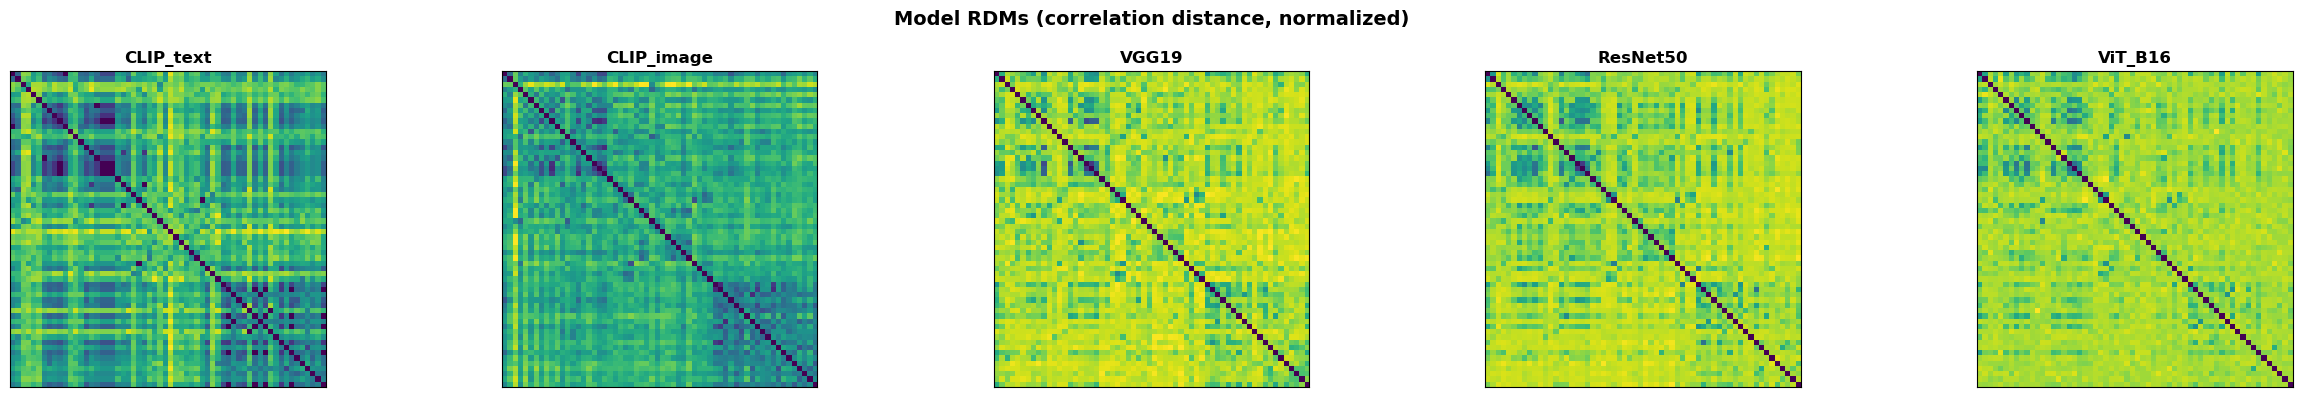

In [9]:
# Visualize all RDMs side by side
fig, axes = plt.subplots(1, 5, figsize=(25, 4))
for ax, (name, rdm) in zip(axes, model_rdms.items()):
    rdm_norm = (rdm - rdm.min()) / (rdm.max() - rdm.min())
    ax.imshow(rdm_norm, cmap='viridis', vmin=0, vmax=1)
    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xticks([])
    ax.set_yticks([])
plt.suptitle('Model RDMs (correlation distance, normalized)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/all_model_rdms.png', dpi=150)
plt.show()

Inter-model RDM correlations (Spearman):
     CLIP_text vs CLIP_image  : r = 0.339
     CLIP_text vs VGG19       : r = 0.442
     CLIP_text vs ResNet50    : r = 0.388
     CLIP_text vs ViT_B16     : r = 0.351
    CLIP_image vs VGG19       : r = 0.448
    CLIP_image vs ResNet50    : r = 0.467
    CLIP_image vs ViT_B16     : r = 0.350
         VGG19 vs ResNet50    : r = 0.726
         VGG19 vs ViT_B16     : r = 0.511
      ResNet50 vs ViT_B16     : r = 0.564


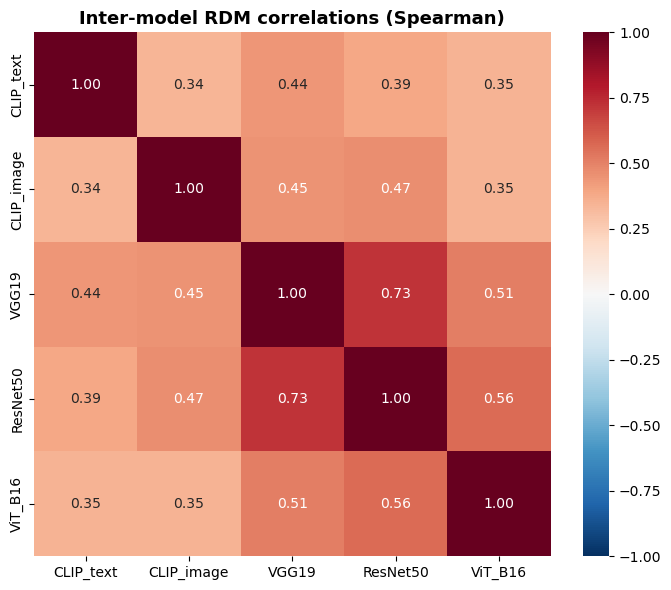

In [10]:
# Inter-model correlations
from scipy.stats import spearmanr

names = list(model_rdms.keys())
n = len(names)
corr_matrix = np.zeros((n, n))

print("Inter-model RDM correlations (Spearman):")
for i in range(n):
    for j in range(n):
        r, _ = spearmanr(upper_tri(model_rdms[names[i]]), upper_tri(model_rdms[names[j]]))
        corr_matrix[i, j] = r
        if j > i:
            print(f"  {names[i]:>12s} vs {names[j]:<12s}: r = {r:.3f}")

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_matrix, xticklabels=names, yticklabels=names,
            annot=True, fmt='.2f', cmap='RdBu_r', vmin=-1, vmax=1, ax=ax)
ax.set_title('Inter-model RDM correlations (Spearman)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('./outputs/inter_model_correlations.png', dpi=150)
plt.show()

## 4. Load fMRI data and run searchlight RSA for each model

In [11]:
# Load fMRI data
tmp_img = nib.load('.\\tmp.img')
mask = np.load('.\\mask.npy')
allsub_avg = np.load('allsub_avg.npy', allow_pickle=True)
centers, neighbors = get_volume_searchlight(mask, radius=5, threshold=0.5)

print(f"Mask shape: {mask.shape}")
print(f"Subject data shape: {allsub_avg.shape}")
print(f"Searchlight centers: {len(centers)}")

Finding searchlights...: 100%|██████████| 59159/59159 [00:06<00:00, 9166.88it/s]


Found 56949 searchlights
Mask shape: (53, 63, 46)
Subject data shape: (20, 60, 153594)
Searchlight centers: 56949


In [12]:
def run_searchlight_for_model(model_name, model_rdm, allsub_avg, centers, neighbors, mask):
    """
    Run searchlight RSA for a single model RDM across all subjects.
    Returns eval_score_list (n_subjects, n_centers) and voxel_indices.
    """
    model_obj = ModelFixed(model_name, upper_tri(model_rdm))
    
    eval_score_list = []
    RDM_brain_list = []
    x, y, z = mask.shape
    
    for i in tqdm(range(allsub_avg.shape[0]), desc=f'{model_name}'):
        subj_data = np.nan_to_num(allsub_avg[i])
        image_value = np.arange(subj_data.shape[0])
        
        SL_RDM = get_searchlight_RDMs(subj_data, centers, neighbors, image_value, method='correlation')
        
        eval_results = evaluate_models_searchlight(SL_RDM, model_obj, eval_fixed, method='spearman', n_jobs=6)
        eval_score = [float(e.evaluations) for e in eval_results]
        
        RDM_brain = np.zeros(x * y * z)
        RDM_brain[list(SL_RDM.rdm_descriptors['voxel_index'])] = eval_score
        RDM_brain = RDM_brain.reshape(x, y, z)
        
        eval_score_list.append(eval_score)
        RDM_brain_list.append(RDM_brain)
    
    voxel_indices = np.array(SL_RDM.rdm_descriptors['voxel_index'])
    return np.array(eval_score_list), RDM_brain_list, voxel_indices


from rsatoolbox.util.searchlight import evaluate_models_searchlight

In [13]:
# Run searchlight for all 5 models
# This will take several hours — each model × 20 subjects × ~57K spheres

searchlight_results = {}

for model_name, model_rdm in model_rdms.items():
    print(f"\n{'='*60}")
    print(f"  Running searchlight for: {model_name}")
    print(f"{'='*60}")
    
    eval_scores, rdm_brains, voxel_ids = run_searchlight_for_model(
        model_name, model_rdm, allsub_avg, centers, neighbors, mask
    )
    
    searchlight_results[model_name] = {
        'eval_scores': eval_scores,
        'rdm_brains': rdm_brains,
        'voxel_indices': voxel_ids,
    }
    
    # Save per-model results
    pd.DataFrame(eval_scores).to_csv(f'./outputs/20sub_SL_eval_{model_name}.csv')
    np.save(f'./outputs/20sub_SL_eval_{model_name}.npy', eval_scores)
    print(f"  Saved. Shape: {eval_scores.shape}")


  Running searchlight for: CLIP_text


Evaluating models for each searchlight: 100%|██████████| 56949/56949 [00:16<00:00, 3555.96it/s]
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_54208\1361822118.py:19: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  eval_score = [float(e.evaluations) for e in eval_results]
CLIP_text:  30%|███       | 6/20 [06:17<14:33, 62.37s/it]c:\Users\yujunchen\AppData\Local\miniconda3\envs\neuro_161\Lib\site-packages\rsatoolbox\data\computations.py:36: RuntimeWarning: invalid value encountered in multiply
  average = np.nan * np.empty(
CLIP_text: 100%|██████████| 20/20 [20:35<00:00, 61.78s/it]


  Saved. Shape: (20, 56949)

  Running searchlight for: CLIP_image


CLIP_image: 100%|██████████| 20/20 [20:16<00:00, 60.83s/it]


  Saved. Shape: (20, 56949)

  Running searchlight for: VGG19


VGG19: 100%|██████████| 20/20 [20:37<00:00, 61.86s/it]


  Saved. Shape: (20, 56949)

  Running searchlight for: ResNet50


ResNet50: 100%|██████████| 20/20 [20:29<00:00, 61.45s/it]


  Saved. Shape: (20, 56949)

  Running searchlight for: ViT_B16


ViT_B16: 100%|██████████| 20/20 [20:44<00:00, 62.22s/it]


  Saved. Shape: (20, 56949)


## 5. Group statistics and t-maps for each model

In [16]:
def compute_tmap_from_scores(eval_scores, voxel_indices, mask_shape, tmp_img,
                              fdr_alpha=0.001, cluster_threshold=30, model_name=''):
    """
    Fisher z-transform -> one-sample t-test -> FDR correction -> 3D t-map.
    """
    # Fisher z
    epsilon = 1e-10
    scores_clipped = np.clip(eval_scores, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(scores_clipped)
    
    # t-test at each voxel
    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0)
    
    # FDR correction
    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)
    sig_voxels = np.where(p_fdr < fdr_alpha)[0]
    
    print(f"{model_name}: {len(sig_voxels)} significant voxels (FDR q < {fdr_alpha})")
    
    # 3D map
    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)
    t_map_3d[t_map_3d < 0] = np.nan
    
    t_img = new_img_like(tmp_img, t_map_3d)
    t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
    
    return t_img_cluster, t_stats, p_fdr


# Compute t-maps for all models
tmaps = {}
for model_name, res in searchlight_results.items():
    tmap, t_stats, p_fdr = compute_tmap_from_scores(
        res['eval_scores'], res['voxel_indices'], mask.shape, tmp_img,
        fdr_alpha=0.001, cluster_threshold=30, model_name=model_name
    )
    tmaps[model_name] = tmap
    
    # Save
    nib.save(tmap, os.path.join('./outputs/tBrainmap', f'tmap_{model_name}_fdr001.nii.gz'))
    print(f"  Saved tmap_{model_name}_fdr001.nii.gz")

CLIP_text: 32262 significant voxels (FDR q < 0.001)
  Saved tmap_CLIP_text_fdr001.nii.gz
CLIP_image: 23527 significant voxels (FDR q < 0.001)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_54208\2561952157.py:28: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_54208\2561952157.py:28: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(t_img, threshold=0, cluster_threshold=cluster_threshold)


  Saved tmap_CLIP_image_fdr001.nii.gz
VGG19: 39684 significant voxels (FDR q < 0.001)
  Saved tmap_VGG19_fdr001.nii.gz
ResNet50: 33542 significant voxels (FDR q < 0.001)
  Saved tmap_ResNet50_fdr001.nii.gz
ViT_B16: 33910 significant voxels (FDR q < 0.001)
  Saved tmap_ViT_B16_fdr001.nii.gz



CLIP_text:



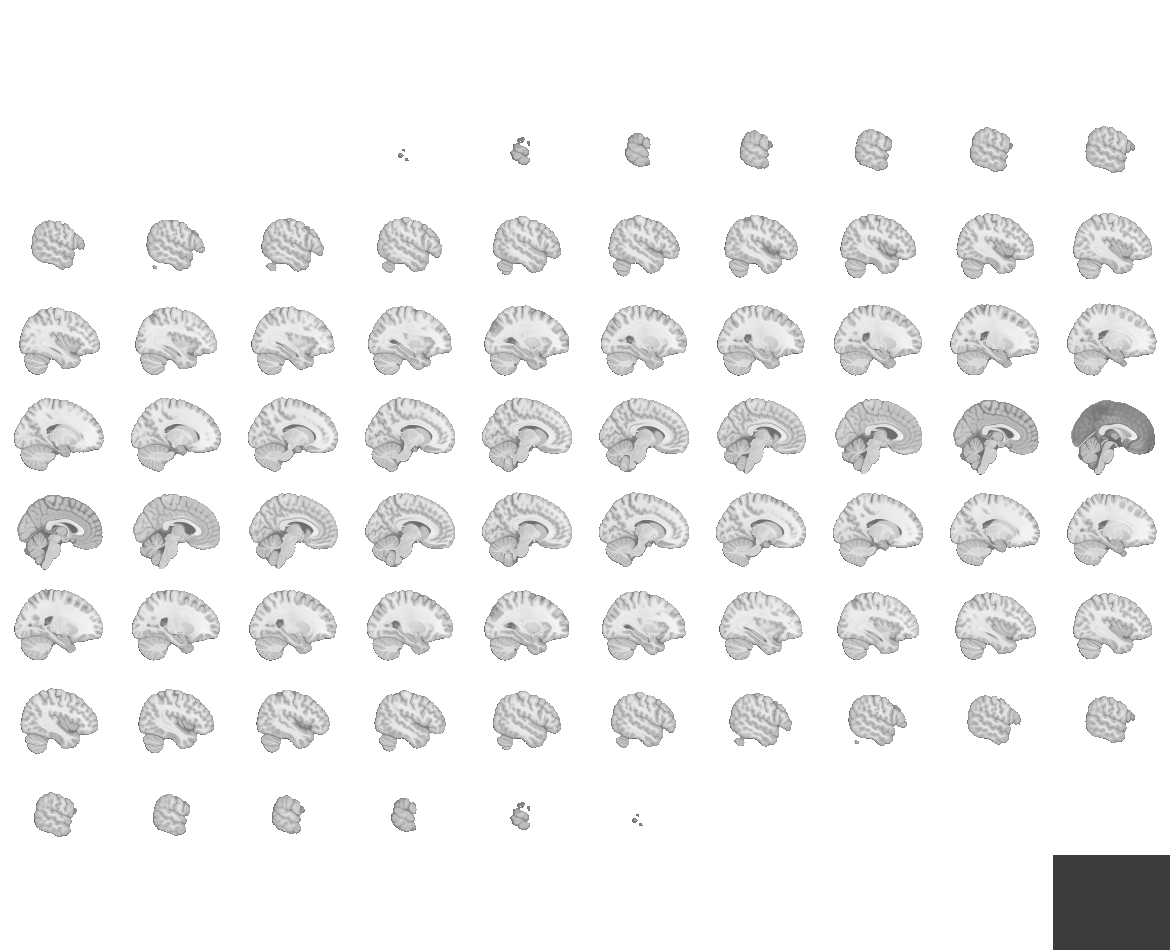
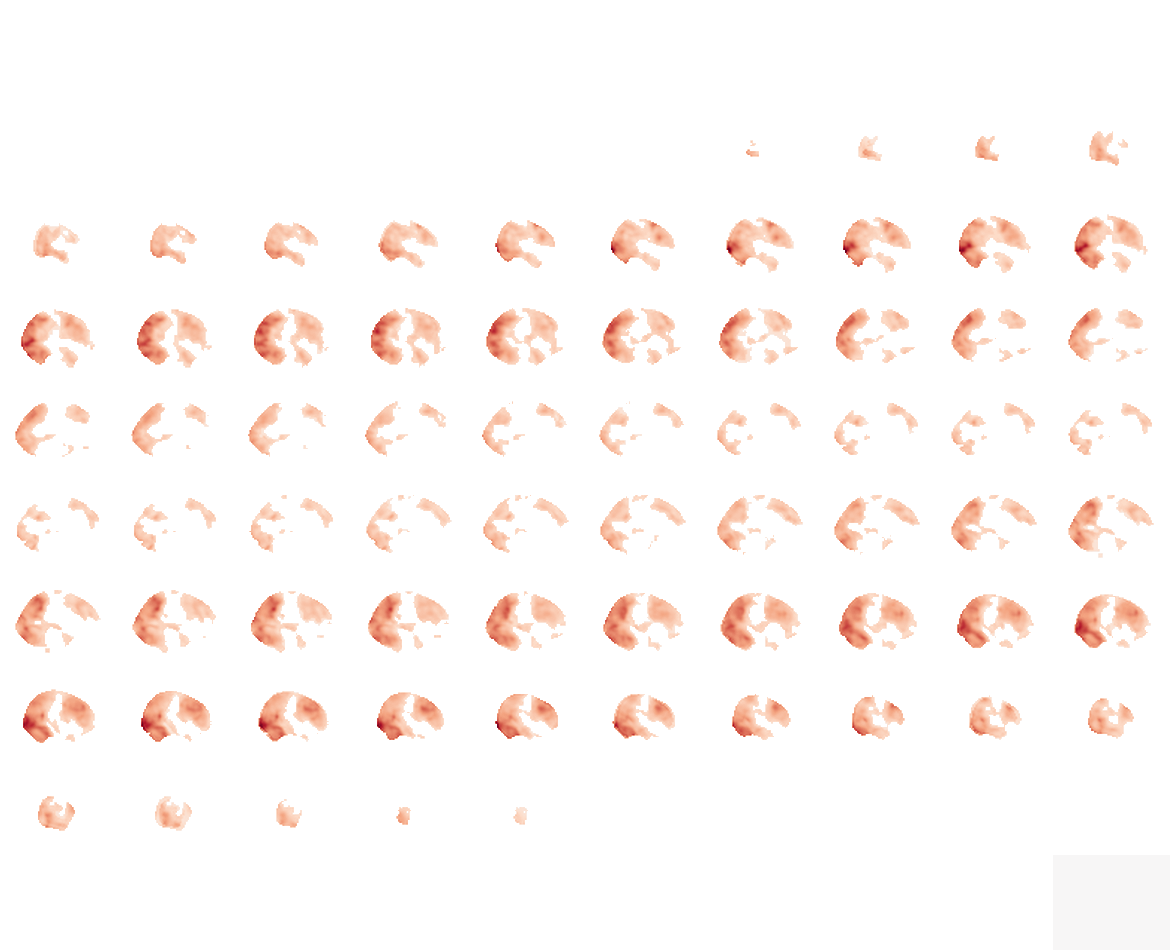


CLIP_image:



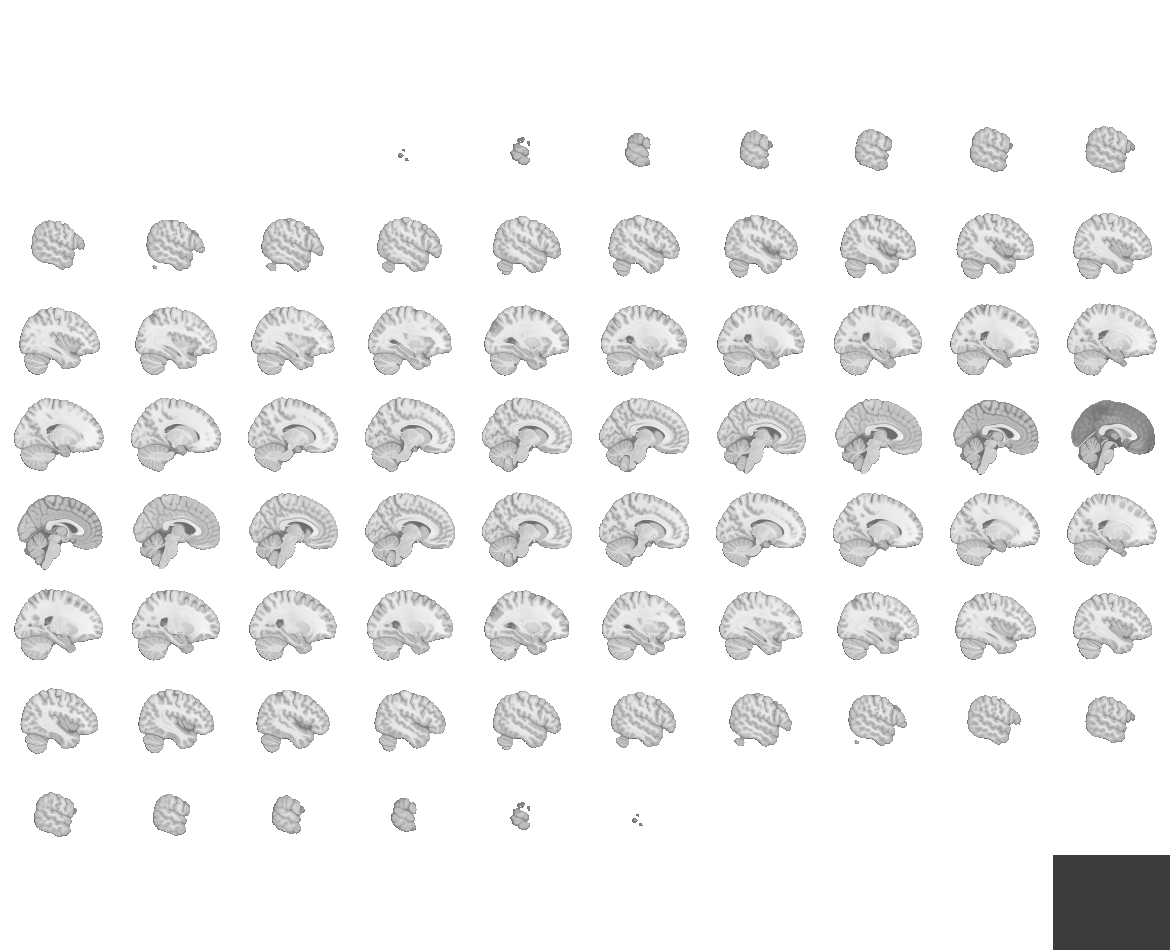
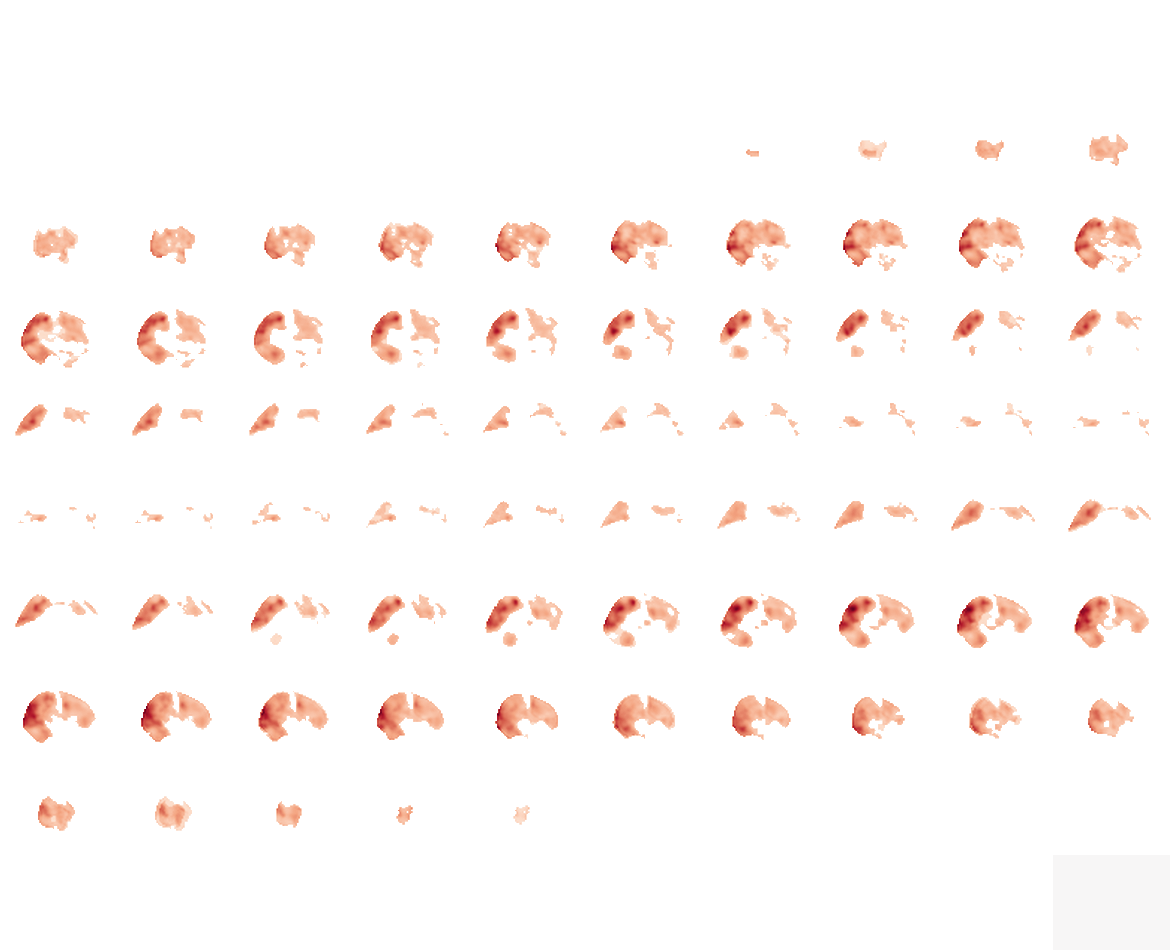


VGG19:



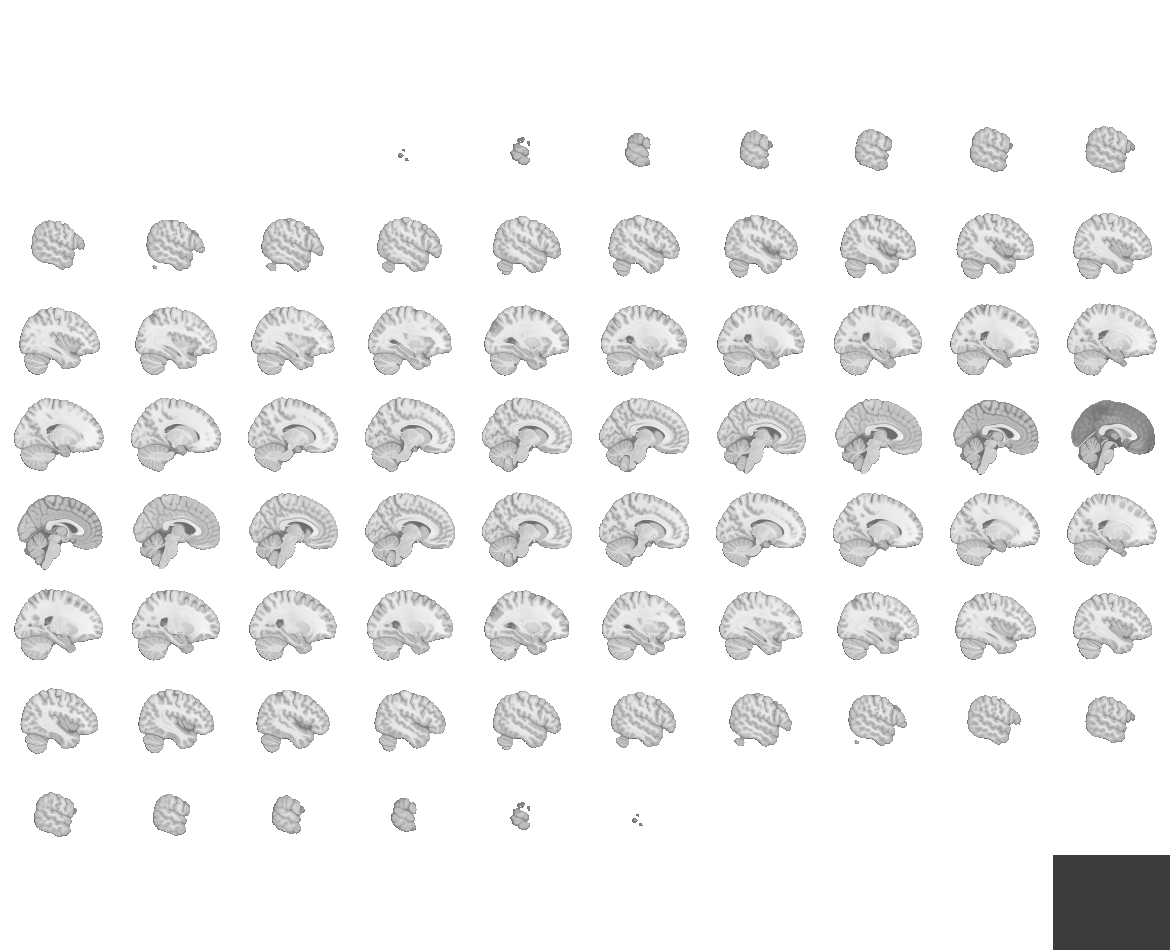
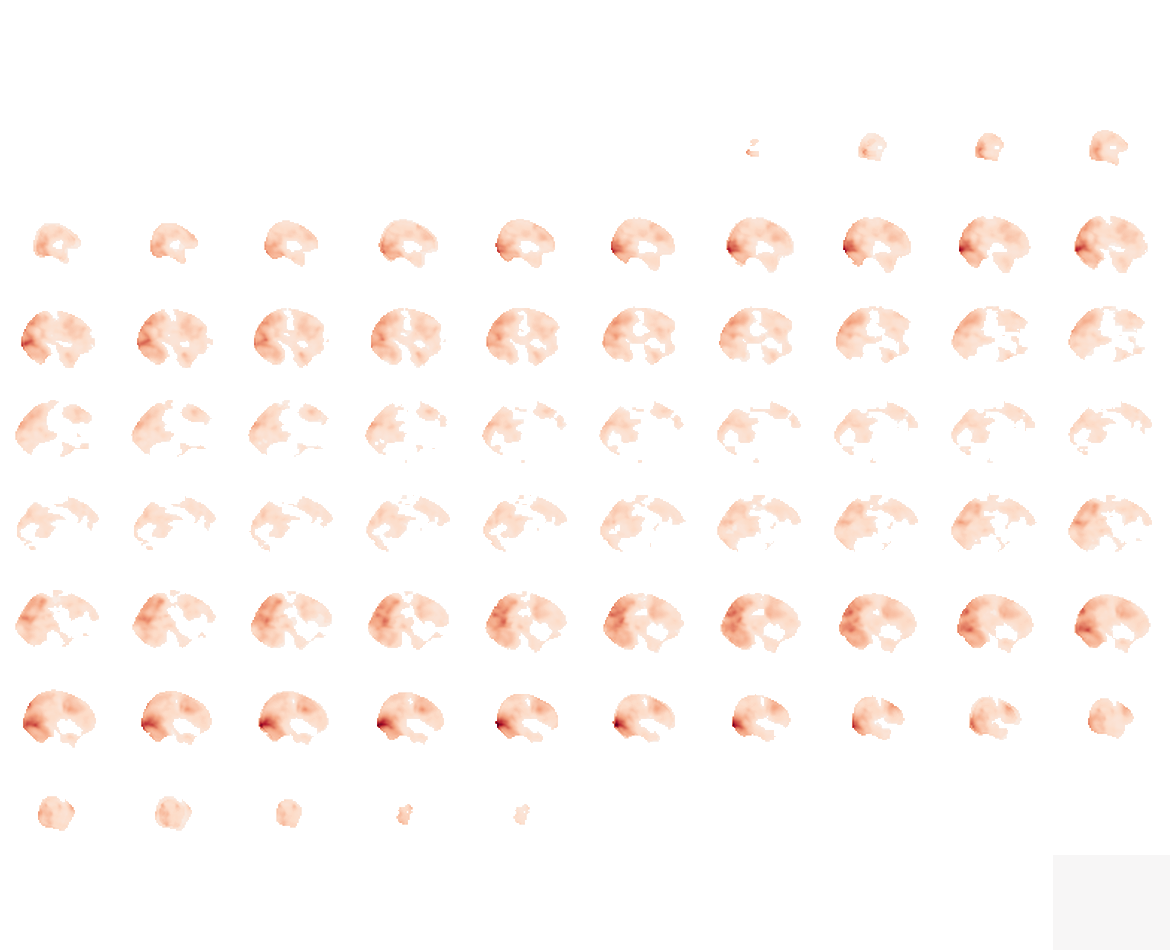


ResNet50:



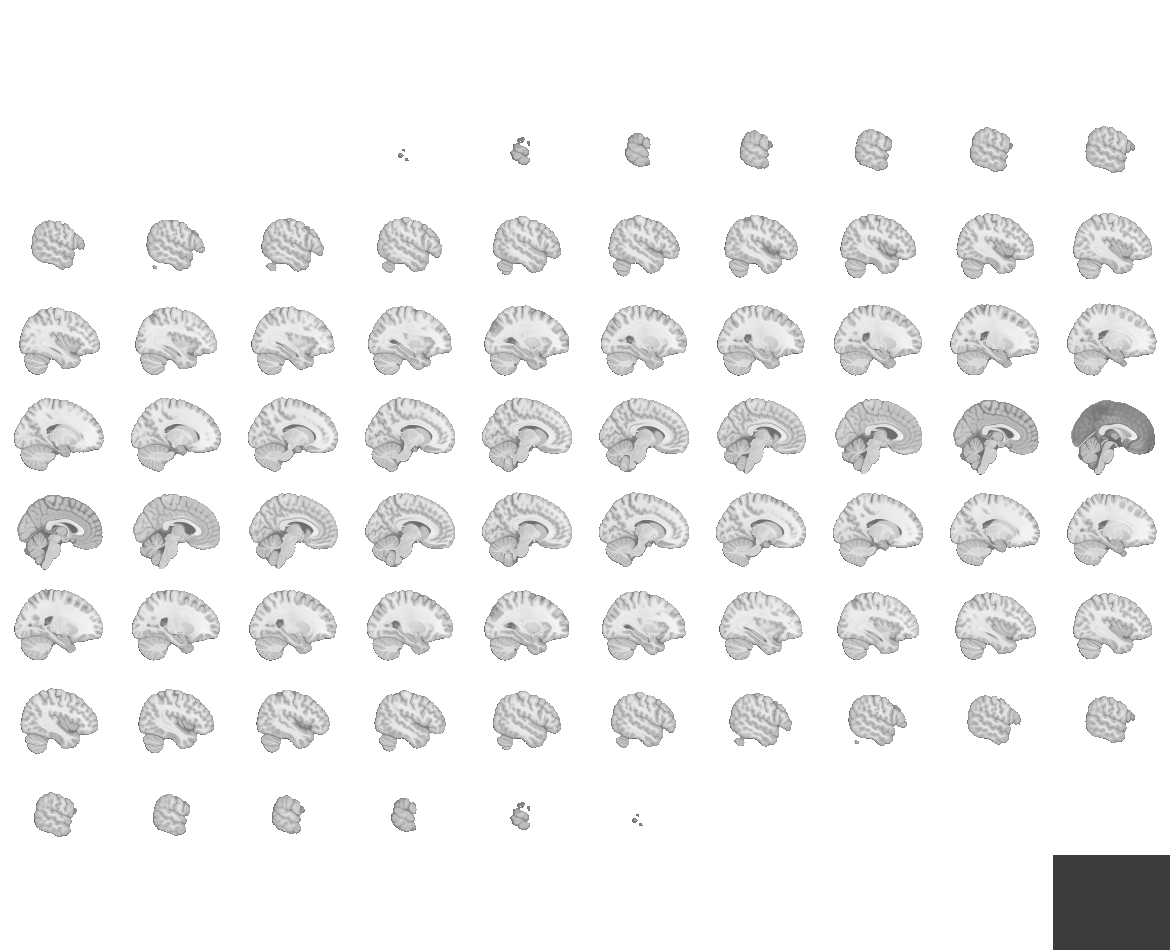
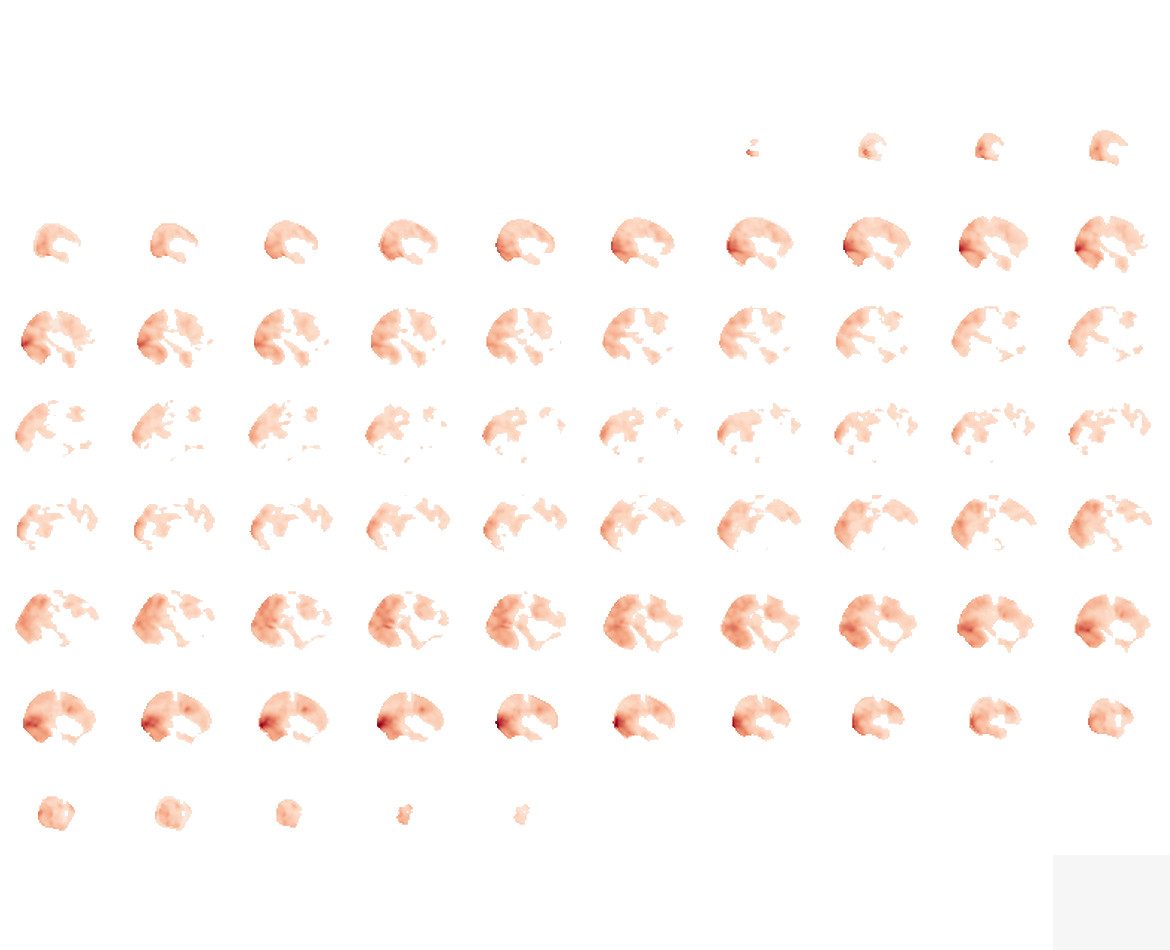


ViT_B16:



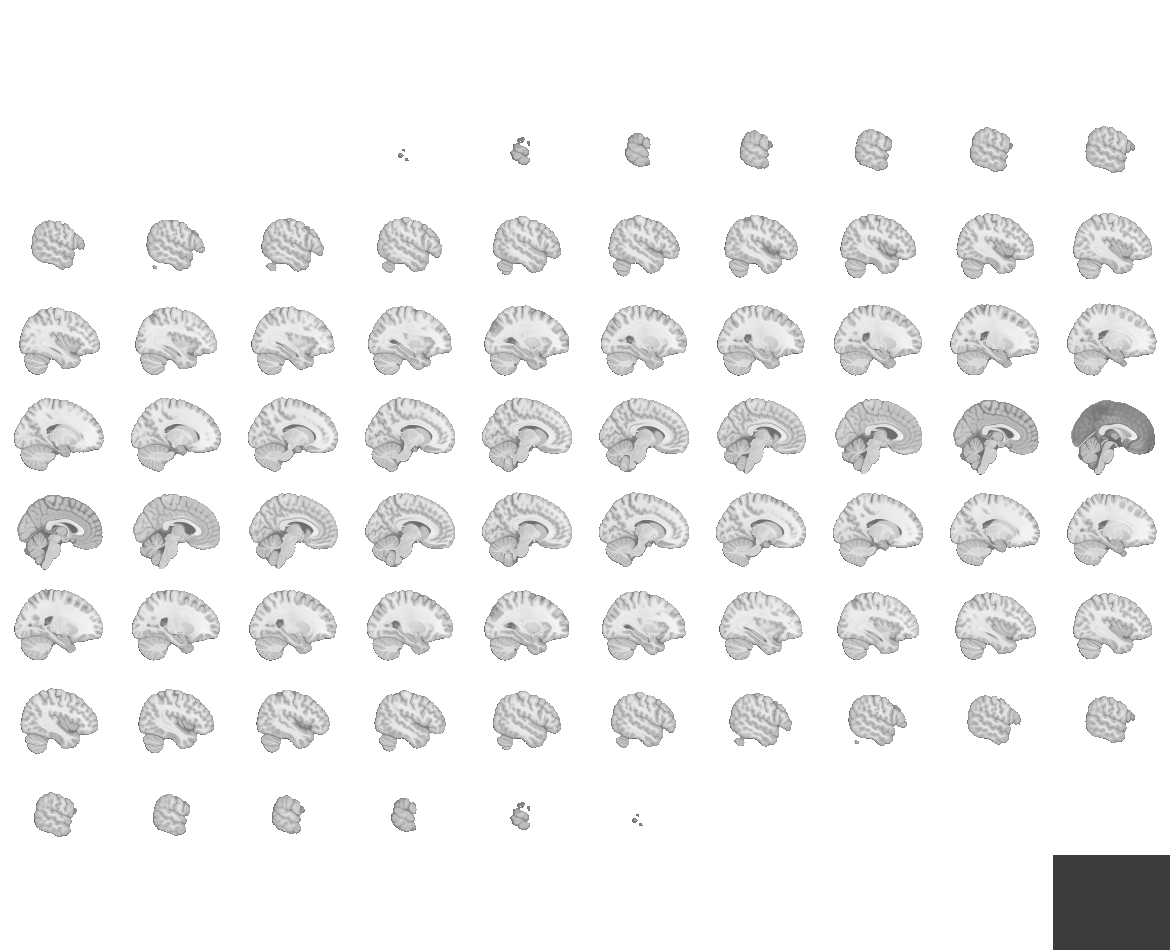
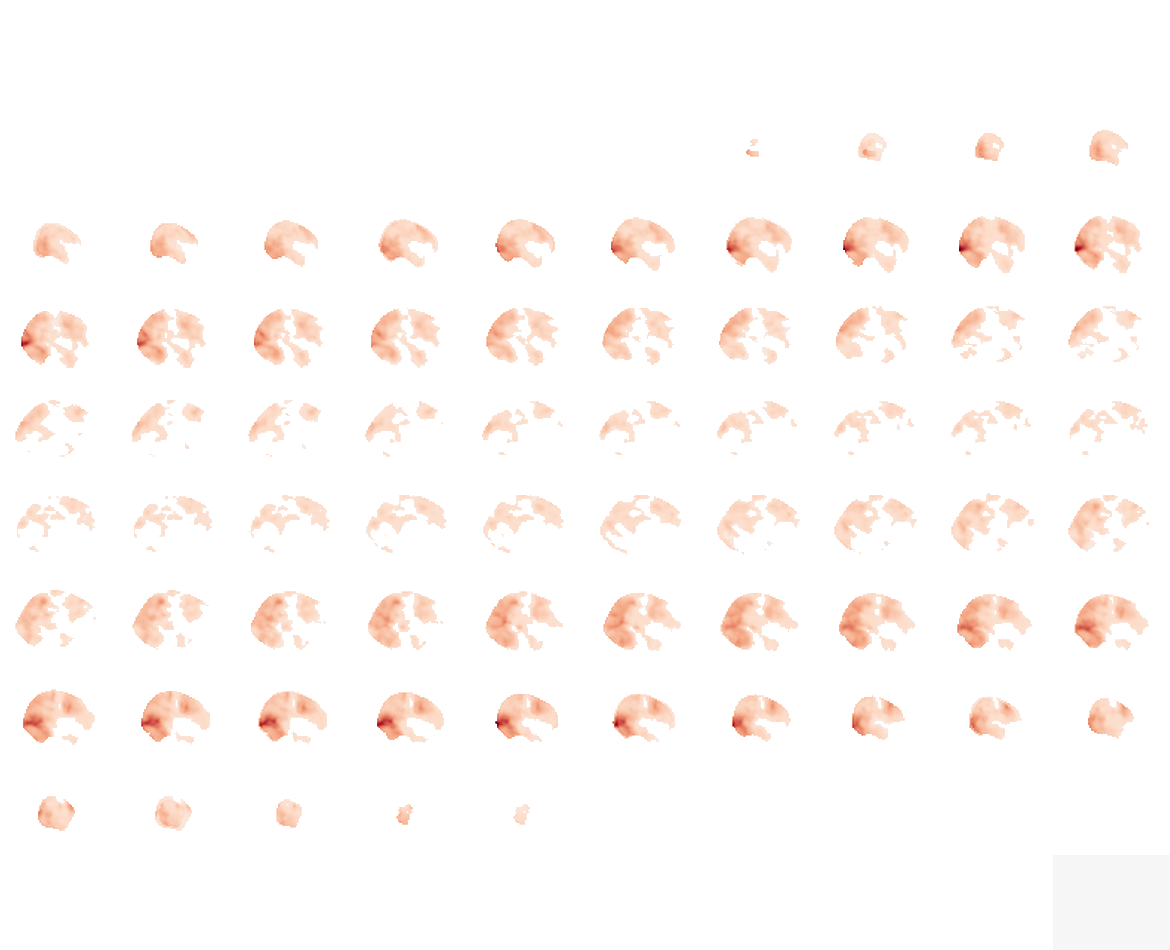

In [17]:
# Visualize all t-maps
for model_name, tmap in tmaps.items():
    print(f"\n{model_name}:")
    view = plotting.view_img(tmap, draw_cross=False, black_bg=False, threshold=0,
                             title=f'{model_name} searchlight RSA')
    display(view)

In [19]:
import os
import numpy as np
import nibabel as nib
from scipy.stats import ttest_1samp
from statsmodels.stats.multitest import fdrcorrection
from nilearn.image import new_img_like
from nilearn import image as nlimg

# Thresholds matched exactly to your model names
t_thresholds = {
    'CLIP_text': 12,
    'CLIP_image': 12,
    'VGG19': 12,
    'ResNet50': 11,
    'ViT_B16': 12,
}

def compute_tmap_from_scores(eval_scores, voxel_indices, mask_shape, tmp_img,
                             fdr_alpha=0.001, cluster_threshold=30,
                             model_name='', t_value_threshold=None):
    """
    Fisher z-transform -> one-sample t-test -> FDR correction
    -> apply model-specific t threshold -> 3D t-map -> cluster threshold
    """
    # Fisher z transform
    epsilon = 1e-10
    scores_clipped = np.clip(eval_scores, -1 + epsilon, 1 - epsilon)
    fisher_z = np.arctanh(scores_clipped)

    # One-sample t-test across subjects
    t_stats, p_values = ttest_1samp(fisher_z, 0, axis=0, nan_policy='omit')

    # FDR correction
    rejected, p_fdr = fdrcorrection(p_values, alpha=fdr_alpha)

    # Start from FDR-significant voxels
    sig_mask = rejected

    # Apply model-specific t threshold
    if t_value_threshold is not None:
        sig_mask = sig_mask & (t_stats >= t_value_threshold)
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha} AND t >= {t_value_threshold})")
    else:
        print(f"{model_name}: {np.sum(sig_mask)} significant voxels "
              f"(FDR q < {fdr_alpha})")

    sig_voxels = np.where(sig_mask)[0]

    # Build 3D t-map
    x, y, z = mask_shape
    t_map = np.full(x * y * z, np.nan)
    t_map[voxel_indices[sig_voxels]] = t_stats[sig_voxels]
    t_map_3d = t_map.reshape(x, y, z)

    # Keep only positive t values
    t_map_3d[t_map_3d < 0] = np.nan

    # Convert to NIfTI
    t_img = new_img_like(tmp_img, t_map_3d)

    # Cluster thresholding
    t_img_cluster = nlimg.threshold_img(
        t_img,
        threshold=0,
        cluster_threshold=cluster_threshold
    )

    return t_img_cluster, t_stats, p_fdr


# Compute t-maps for all models
tmaps = {}
out_dir = './outputs/tBrainmap'
os.makedirs(out_dir, exist_ok=True)

for model_name, res in searchlight_results.items():
    t_thr = t_thresholds.get(model_name, None)

    tmap, t_stats, p_fdr = compute_tmap_from_scores(
        res['eval_scores'],
        res['voxel_indices'],
        mask.shape,
        tmp_img,
        fdr_alpha=0.001,
        cluster_threshold=30,
        model_name=model_name,
        t_value_threshold=t_thr
    )

    tmaps[model_name] = tmap

    thr_label = f"t{t_thr}" if t_thr is not None else "tNone"
    out_path = os.path.join(out_dir, f'tmap_{model_name}_fdr001_{thr_label}.nii.gz')
    nib.save(tmap, out_path)
    print(f"  Saved {os.path.basename(out_path)}")

CLIP_text: 1754 significant voxels (FDR q < 0.001 AND t >= 12)


C:\Users\yujunchen\AppData\Local\Temp\ipykernel_54208\1073911914.py:63: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  t_img_cluster = nlimg.threshold_img(
C:\Users\yujunchen\AppData\Local\Temp\ipykernel_54208\1073911914.py:63: UserWarning: Non-finite values detected. These values will be replaced with zeros.
  t_img_cluster = nlimg.threshold_img(


  Saved tmap_CLIP_text_fdr001_t12.nii.gz
CLIP_image: 657 significant voxels (FDR q < 0.001 AND t >= 12)
  Saved tmap_CLIP_image_fdr001_t12.nii.gz
VGG19: 3155 significant voxels (FDR q < 0.001 AND t >= 12)
  Saved tmap_VGG19_fdr001_t12.nii.gz
ResNet50: 1576 significant voxels (FDR q < 0.001 AND t >= 11)
  Saved tmap_ResNet50_fdr001_t11.nii.gz
ViT_B16: 1350 significant voxels (FDR q < 0.001 AND t >= 12)
  Saved tmap_ViT_B16_fdr001_t12.nii.gz


## 6. Load saved results (if restarting)

Uncomment and run if you've already computed the searchlight and just want to reload.

In [ ]:
# # Reload saved results
# searchlight_results = {}
# for model_name in ['CLIP_text', 'CLIP_image', 'VGG19', 'ResNet50', 'ViT_B16']:
#     eval_scores = np.load(f'./outputs/20sub_SL_eval_{model_name}.npy')
#     searchlight_results[model_name] = {'eval_scores': eval_scores}
#     print(f"{model_name}: {eval_scores.shape}")